DATA AWAL
Jumlah baris : 26620
Jumlah SID   : 521

Setelah cleaning:
Jumlah baris : 26620
Jumlah SID   : 521

DATA TRAJEKTORI PENELITIAN
Jumlah SID penelitian : 392
Jumlah titik track    : 17885

Distribusi zona genesis:
zone
Utara         354
Ekuatorial      2
Selatan        36
Name: count, dtype: int64

Jumlah trajektori berhasil dihitung: 392

Excel berhasil disimpan:
output_3_1_2\Data_Pendukung_3_1_2_1_Trajektori.xlsx


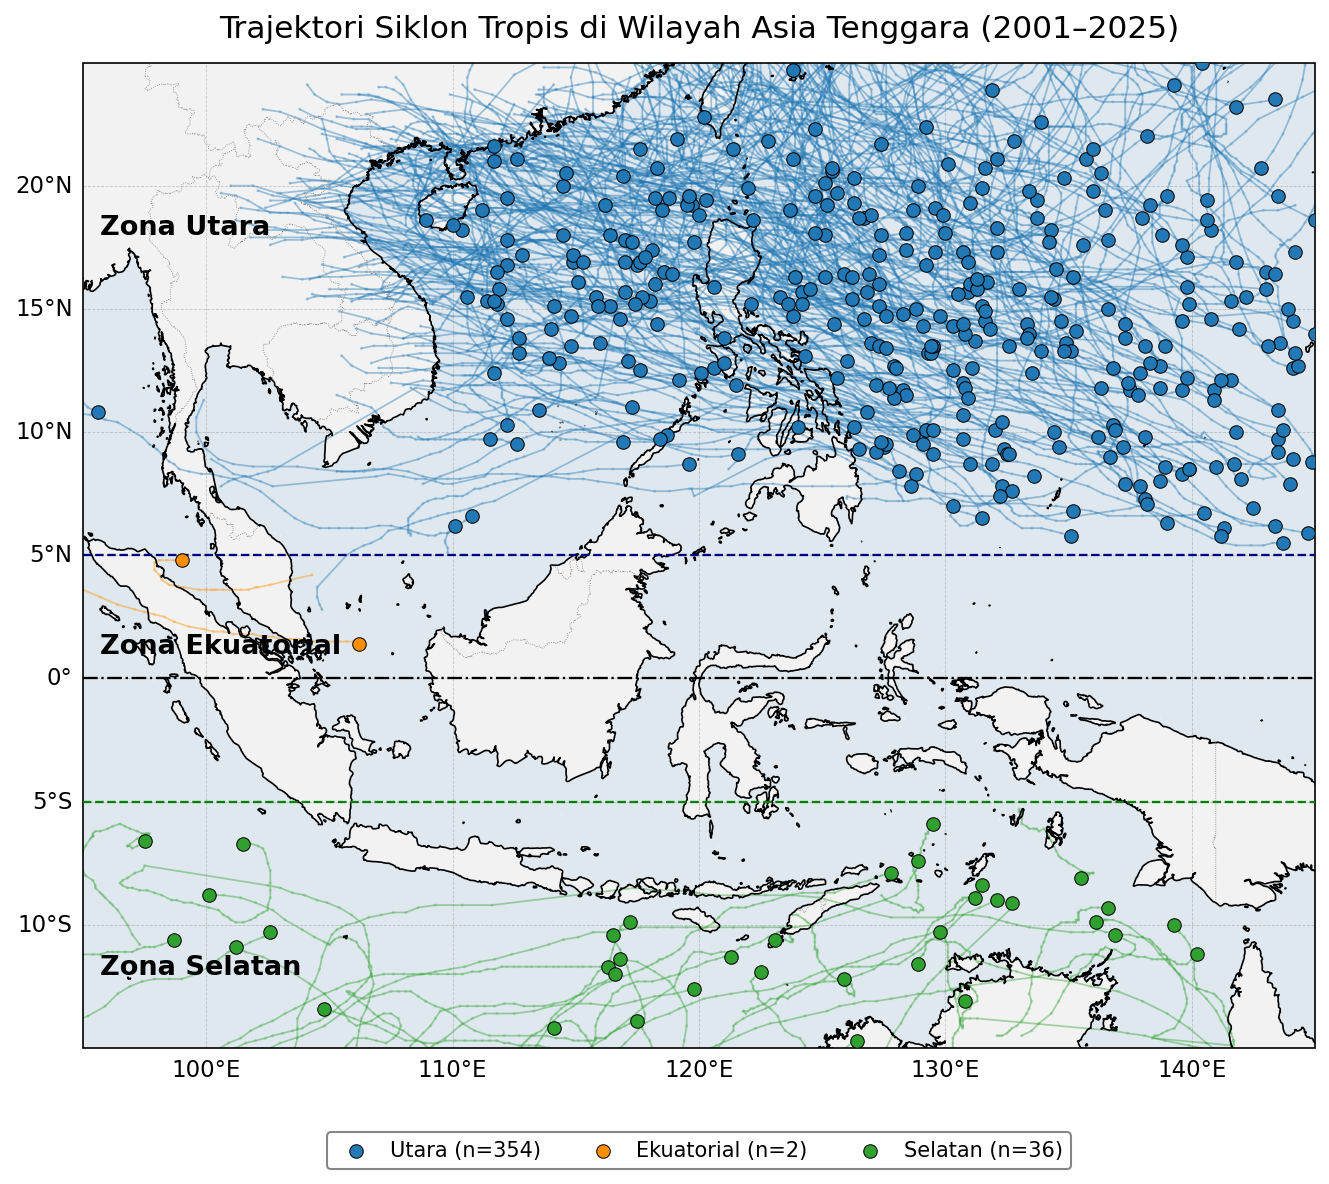


Gambar 3.5 berhasil disimpan:
output_3_1_2\Gambar_3.5_Peta_Seluruh_Trajektori.png

RINGKASAN FINAL 3.1.2.1
Jumlah trajektori       : 392
Panjang rata-rata       : 2379.60 km
Median panjang          : 2315.57 km
Panjang minimum         : 140.39 km
Panjang maksimum        : 7487.85 km
Standar deviasi panjang : 1074.33 km
Durasi rata-rata        : 135.08 jam (5.63 hari)
Median durasi           : 129.00 jam (5.38 hari)
Durasi minimum          : 15.00 jam
Durasi maksimum         : 477.00 jam
Standar deviasi durasi  : 63.49 jam
Arah dominan            : Barat Laut
Jumlah arah dominan     : 126
Persentase arah dominan : 32.14%

Distribusi arah:
             Arah  Jumlah Kejadian  Persentase (%)
            Utara               74           18.88
       Timur Laut               34            8.67
            Timur                2            0.51
         Tenggara                6            1.53
          Selatan                9            2.30
       Barat Daya               18            4

In [3]:
# ============================================================
# BAB III - 3.1.2.1
# KARAKTERISTIK TRAJEKTORI KESELURUHAN
#
# Dataset:
# Siklon_Tropis_ERA5_Extracted.xlsx
#
# Domain pemilihan GENESIS:
# 95°BT – 145°BT
# 15°LS – 25°LU
#
# Output:
# - Gambar 3.5 Peta seluruh trajektori
# - Data pendukung karakteristik trajektori dalam Excel
#
# CATATAN:
# Ringkasan trajektori TIDAK diberi nomor Tabel 3.3,
# karena sesuai draft:
# Tabel 3.3 = hasil evaluasi clustering / Silhouette Score.
# ============================================================


# ============================================================
# 0. IMPORT LIBRARY
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cartopy.mpl.gridliner import (
    LONGITUDE_FORMATTER,
    LATITUDE_FORMATTER
)

from openpyxl import load_workbook

from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)


# ============================================================
# 1. PENGATURAN FILE
# ============================================================

FILE_PATH = "Siklon_Tropis_ERA5_Extracted.xlsx"
SHEET_NAME = "Sheet1"

OUTPUT_DIR = "output_3_1_2"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 2. DOMAIN PENELITIAN
# ============================================================

LON_MIN = 95
LON_MAX = 145

LAT_MIN = -15
LAT_MAX = 25

# Batas zona ekuatorial
EQ_MIN = -5
EQ_MAX = 5


# ============================================================
# 3. PENGATURAN VISUAL
# ============================================================

plt.rcParams.update({

    "font.size": 11,

    "axes.labelsize": 12,

    "axes.titlesize": 14,

    "figure.dpi": 150,

    "savefig.dpi": 300,

    "font.family": "DejaVu Sans"

})


# Warna berdasarkan zona genesis
ZONE_COLORS = {

    "Utara":
        "#1f77b4",

    "Ekuatorial":
        "#ff8c00",

    "Selatan":
        "#2ca02c"

}


ZONE_ORDER = [

    "Utara",

    "Ekuatorial",

    "Selatan"

]


# ============================================================
# 4. MEMBACA DATA
# ============================================================

df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME
)


print("=" * 65)
print("DATA AWAL")
print("=" * 65)

print(
    "Jumlah baris :",
    len(df)
)

print(
    "Jumlah SID   :",
    df["SID"].nunique()
)


# ============================================================
# 5. CLEANING DATA
# ============================================================

# Waktu
df["ISO_TIME"] = pd.to_datetime(
    df["ISO_TIME"],
    errors="coerce"
)


# Latitude
df["LAT"] = pd.to_numeric(
    df["LAT"],
    errors="coerce"
)


# Longitude
df["LON"] = pd.to_numeric(
    df["LON"],
    errors="coerce"
)


# Hapus data penting yang kosong
df = df.dropna(
    subset=[
        "SID",
        "ISO_TIME",
        "LAT",
        "LON"
    ]
).copy()


# Validasi latitude
df = df[
    df["LAT"].between(
        -90,
        90
    )
].copy()


# Validasi longitude
df = df[
    df["LON"].between(
        -180,
        360
    )
].copy()


# Hilangkan SID-waktu duplikat
df = df.drop_duplicates(
    subset=[
        "SID",
        "ISO_TIME"
    ],
    keep="first"
)


# Urutkan berdasarkan SID dan waktu
df = df.sort_values(
    [
        "SID",
        "ISO_TIME"
    ]
).reset_index(
    drop=True
)


print("\nSetelah cleaning:")

print(
    "Jumlah baris :",
    len(df)
)

print(
    "Jumlah SID   :",
    df["SID"].nunique()
)


# ============================================================
# 6. IDENTIFIKASI GENESIS SELURUH SID
# ============================================================
#
# Karena sudah diurutkan berdasarkan waktu,
# baris pertama masing-masing SID adalah genesis.
# ============================================================

genesis_all = (

    df.drop_duplicates(
        subset="SID",
        keep="first"
    )

    .copy()

)


# ============================================================
# 7. FILTER GENESIS BERDASARKAN DOMAIN PENELITIAN
# ============================================================

genesis = genesis_all[

    genesis_all["LON"].between(
        LON_MIN,
        LON_MAX,
        inclusive="both"
    )

    &

    genesis_all["LAT"].between(
        LAT_MIN,
        LAT_MAX,
        inclusive="both"
    )

].copy()


# ============================================================
# 8. KLASIFIKASI ZONA GENESIS
# ============================================================

def get_zone(lat):

    if EQ_MIN <= lat <= EQ_MAX:

        return "Ekuatorial"

    elif lat > EQ_MAX:

        return "Utara"

    else:

        return "Selatan"


genesis["zone"] = (

    genesis["LAT"]

    .apply(
        get_zone
    )

)


# ============================================================
# 9. PILIH SID PENELITIAN
# ============================================================

selected_sids = (

    genesis["SID"]

    .unique()

)


# Ambil SELURUH lintasan dari SID terpilih
track = df[

    df["SID"].isin(
        selected_sids
    )

].copy()


print("\n" + "=" * 65)
print("DATA TRAJEKTORI PENELITIAN")
print("=" * 65)


print(
    "Jumlah SID penelitian :",
    len(selected_sids)
)


print(
    "Jumlah titik track    :",
    len(track)
)


print("\nDistribusi zona genesis:")

print(

    genesis["zone"]

    .value_counts()

    .reindex(
        ZONE_ORDER,
        fill_value=0
    )

)


print("=" * 65)


# Quality control
if len(selected_sids) != 392:

    print(
        "\nPERINGATAN:"
        "\nJumlah SID penelitian bukan 392."
        "\nPeriksa dataset atau preprocessing."
    )


# ============================================================
# 10. FUNGSI HAVERSINE
# ============================================================

EARTH_RADIUS_KM = 6371.0088


def haversine(
    lat1,
    lon1,
    lat2,
    lon2
):

    lat1 = np.radians(
        lat1
    )

    lon1 = np.radians(
        lon1
    )

    lat2 = np.radians(
        lat2
    )

    lon2 = np.radians(
        lon2
    )


    dlat = (
        lat2 - lat1
    )

    dlon = (
        lon2 - lon1
    )


    a = (

        np.sin(
            dlat / 2
        ) ** 2

        +

        np.cos(
            lat1
        )

        *

        np.cos(
            lat2
        )

        *

        np.sin(
            dlon / 2
        ) ** 2

    )


    c = (

        2

        *

        np.arctan2(

            np.sqrt(a),

            np.sqrt(
                1 - a
            )

        )

    )


    return (

        EARTH_RADIUS_KM

        *

        c

    )


# ============================================================
# 11. FUNGSI BEARING
# ============================================================

def calculate_bearing(
    lat1,
    lon1,
    lat2,
    lon2
):

    lat1 = np.radians(
        lat1
    )

    lat2 = np.radians(
        lat2
    )


    delta_lon = np.radians(
        lon2 - lon1
    )


    x = (

        np.sin(
            delta_lon
        )

        *

        np.cos(
            lat2
        )

    )


    y = (

        np.cos(
            lat1
        )

        *

        np.sin(
            lat2
        )

        -

        np.sin(
            lat1
        )

        *

        np.cos(
            lat2
        )

        *

        np.cos(
            delta_lon
        )

    )


    bearing = np.degrees(

        np.arctan2(
            x,
            y
        )

    )


    return (

        bearing + 360

    ) % 360


# ============================================================
# 12. KLASIFIKASI ARAH
# ============================================================

def bearing_to_direction(
    bearing
):

    if pd.isna(
        bearing
    ):

        return "Tidak terdefinisi"


    directions = [

        "Utara",

        "Timur Laut",

        "Timur",

        "Tenggara",

        "Selatan",

        "Barat Daya",

        "Barat",

        "Barat Laut"

    ]


    index = int(

        (

            (
                bearing + 22.5
            )

            %

            360

        )

        /

        45

    )


    return (

        directions[
            index
        ]

    )


# ============================================================
# 13. HITUNG KARAKTERISTIK SETIAP SID
# ============================================================

records = []


for sid, g in track.groupby(
    "SID"
):


    g = (

        g.sort_values(
            "ISO_TIME"
        )

        .copy()

    )


    # --------------------------------------------------------
    # Genesis dan terminasi
    # --------------------------------------------------------

    genesis_row = (
        g.iloc[0]
    )


    termination_row = (
        g.iloc[-1]
    )


    genesis_time = (
        genesis_row[
            "ISO_TIME"
        ]
    )


    genesis_lat = (
        genesis_row[
            "LAT"
        ]
    )


    genesis_lon = (
        genesis_row[
            "LON"
        ]
    )


    termination_time = (
        termination_row[
            "ISO_TIME"
        ]
    )


    termination_lat = (
        termination_row[
            "LAT"
        ]
    )


    termination_lon = (
        termination_row[
            "LON"
        ]
    )


    # --------------------------------------------------------
    # Durasi
    # --------------------------------------------------------

    duration_hours = (

        (
            termination_time
            -
            genesis_time
        )

        .total_seconds()

        /

        3600

    )


    duration_days = (

        duration_hours

        /

        24

    )


    # --------------------------------------------------------
    # Panjang lintasan
    # --------------------------------------------------------

    lat_values = (

        g["LAT"]

        .to_numpy()

    )


    lon_values = (

        g["LON"]

        .to_numpy()

    )


    if len(g) >= 2:


        segment_distances = haversine(

            lat_values[:-1],

            lon_values[:-1],

            lat_values[1:],

            lon_values[1:]

        )


        track_length_km = (

            np.nansum(
                segment_distances
            )

        )


    else:


        track_length_km = 0.0


    # --------------------------------------------------------
    # Jarak genesis -> terminasi
    # --------------------------------------------------------

    displacement_km = haversine(

        genesis_lat,

        genesis_lon,

        termination_lat,

        termination_lon

    )


    # --------------------------------------------------------
    # Bearing
    # --------------------------------------------------------

    if displacement_km < 1:


        bearing = np.nan


        direction = (
            "Tidak terdefinisi"
        )


    else:


        bearing = calculate_bearing(

            genesis_lat,

            genesis_lon,

            termination_lat,

            termination_lon

        )


        direction = bearing_to_direction(
            bearing
        )


    # --------------------------------------------------------
    # Nama siklon
    # --------------------------------------------------------

    if "NAME" in g.columns:

        storm_name = genesis_row[
            "NAME"
        ]

    else:

        storm_name = ""


    # --------------------------------------------------------
    # Season
    # --------------------------------------------------------

    if "SEASON" in g.columns:

        season = genesis_row[
            "SEASON"
        ]

    else:

        season = (
            genesis_time.year
        )


    # --------------------------------------------------------
    # Simpan
    # --------------------------------------------------------

    records.append({

        "SID":
            sid,

        "NAME":
            storm_name,

        "SEASON":
            season,


        "Genesis_Time":
            genesis_time,

        "Genesis_Lat":
            genesis_lat,

        "Genesis_Lon":
            genesis_lon,


        "Termination_Time":
            termination_time,

        "Termination_Lat":
            termination_lat,

        "Termination_Lon":
            termination_lon,


        "Genesis_Zone":
            get_zone(
                genesis_lat
            ),


        "Number_of_Points":
            len(g),


        "Duration_Hours":
            duration_hours,

        "Duration_Days":
            duration_days,


        "Track_Length_km":
            track_length_km,


        "Genesis_Termination_Distance_km":
            displacement_km,


        "Bearing_deg":
            bearing,


        "Direction":
            direction

    })


trajectory_df = pd.DataFrame(
    records
)


print(
    "\nJumlah trajektori berhasil dihitung:",
    len(
        trajectory_df
    )
)


# ============================================================
# 14. RINGKASAN STATISTIK TRAJEKTORI
# ============================================================
#
# Ini DATA PENDUKUNG 3.1.2.1.
# Tidak diberi nomor Tabel 3.3.
# ============================================================

summary_trajectory = pd.DataFrame({

    "Karakteristik": [

        "Panjang lintasan (km)",

        "Durasi (jam)"

    ],


    "Rata-rata": [

        trajectory_df[
            "Track_Length_km"
        ].mean(),

        trajectory_df[
            "Duration_Hours"
        ].mean()

    ],


    "Median": [

        trajectory_df[
            "Track_Length_km"
        ].median(),

        trajectory_df[
            "Duration_Hours"
        ].median()

    ],


    "Minimum": [

        trajectory_df[
            "Track_Length_km"
        ].min(),

        trajectory_df[
            "Duration_Hours"
        ].min()

    ],


    "Maksimum": [

        trajectory_df[
            "Track_Length_km"
        ].max(),

        trajectory_df[
            "Duration_Hours"
        ].max()

    ],


    "Standar Deviasi": [

        trajectory_df[
            "Track_Length_km"
        ].std(),

        trajectory_df[
            "Duration_Hours"
        ].std()

    ]

})


# ============================================================
# 15. DISTRIBUSI ARAH
# ============================================================

DIRECTION_ORDER = [

    "Utara",

    "Timur Laut",

    "Timur",

    "Tenggara",

    "Selatan",

    "Barat Daya",

    "Barat",

    "Barat Laut",

    "Tidak terdefinisi"

]


direction_df = (

    trajectory_df[
        "Direction"
    ]

    .value_counts()

    .reindex(
        DIRECTION_ORDER,
        fill_value=0
    )

    .rename_axis(
        "Arah"
    )

    .reset_index(
        name="Jumlah Kejadian"
    )

)


direction_df[
    "Persentase (%)"
] = (

    direction_df[
        "Jumlah Kejadian"
    ]

    /

    len(
        trajectory_df
    )

    *

    100

)


# ============================================================
# 16. QUALITY CONTROL ZONA
# ============================================================

qc_zone = (

    trajectory_df[
        "Genesis_Zone"
    ]

    .value_counts()

    .reindex(
        ZONE_ORDER,
        fill_value=0
    )

    .rename_axis(
        "Zona Genesis"
    )

    .reset_index(
        name="Jumlah Kejadian"
    )

)


qc_zone[
    "Persentase (%)"
] = (

    qc_zone[
        "Jumlah Kejadian"
    ]

    /

    len(
        trajectory_df
    )

    *

    100

)


# ============================================================
# 17. SIMPAN EXCEL DATA PENDUKUNG
# ============================================================

OUTPUT_EXCEL = os.path.join(

    OUTPUT_DIR,

    "Data_Pendukung_3_1_2_1_Trajektori.xlsx"

)


with pd.ExcelWriter(

    OUTPUT_EXCEL,

    engine="openpyxl"

) as writer:


    summary_trajectory.round(
        2
    ).to_excel(

        writer,

        sheet_name="Ringkasan Trajektori",

        index=False

    )


    direction_df.round(
        2
    ).to_excel(

        writer,

        sheet_name="Distribusi Arah",

        index=False

    )


    trajectory_df.to_excel(

        writer,

        sheet_name="Karakteristik per SID",

        index=False

    )


    qc_zone.round(
        2
    ).to_excel(

        writer,

        sheet_name="QC Zona",

        index=False

    )


# ============================================================
# 18. FORMAT EXCEL
# ============================================================

wb = load_workbook(
    OUTPUT_EXCEL
)


header_fill = PatternFill(
    "solid",
    fgColor="D9EAF7"
)


header_font = Font(
    bold=True
)


thin_border = Border(

    left=Side(
        style="thin",
        color="BFBFBF"
    ),

    right=Side(
        style="thin",
        color="BFBFBF"
    ),

    top=Side(
        style="thin",
        color="BFBFBF"
    ),

    bottom=Side(
        style="thin",
        color="BFBFBF"
    )

)


for ws in wb.worksheets:


    ws.freeze_panes = "A2"


    # Header
    for cell in ws[1]:


        cell.fill = (
            header_fill
        )


        cell.font = (
            header_font
        )


        cell.alignment = Alignment(

            horizontal="center",

            vertical="center"

        )


    # Border
    for row in ws.iter_rows():


        for cell in row:


            cell.border = (
                thin_border
            )


            cell.alignment = Alignment(
                vertical="center"
            )


    # Lebar kolom otomatis
    for column_cells in ws.columns:


        column_letter = (

            column_cells[0]
            .column_letter

        )


        max_length = 0


        for cell in column_cells:


            if cell.value is not None:


                max_length = max(

                    max_length,

                    len(
                        str(
                            cell.value
                        )
                    )

                )


        ws.column_dimensions[
            column_letter
        ].width = min(

            max_length + 2,

            35

        )


wb.save(
    OUTPUT_EXCEL
)


print(
    "\nExcel berhasil disimpan:"
)

print(
    OUTPUT_EXCEL
)


# ============================================================
# ============================================================
#
#                    GAMBAR 3.5
#
#             SELURUH TRAJEKTORI
#
# ============================================================
# ============================================================

OUTPUT_G35 = os.path.join(

    OUTPUT_DIR,

    "Gambar_3.5_Peta_Seluruh_Trajektori.png"

)


# ============================================================
# 19. PENGATURAN VISUAL TRACK
# ============================================================

TRACK_LINEWIDTH = 0.85

TRACK_ALPHA = 0.42

TRACK_POINT_SIZE = 2.5

TRACK_POINT_ALPHA = 0.20

GENESIS_POINT_SIZE = 42


# ============================================================
# 20. LOOKUP ZONA BERDASARKAN SID
# ============================================================

sid_to_zone = (

    genesis

    .set_index(
        "SID"
    )[
        "zone"
    ]

    .to_dict()

)


# ============================================================
# 21. BUAT FIGURE
# ============================================================

fig = plt.figure(
    figsize=(12, 9)
)


ax = plt.axes(
    projection=ccrs.PlateCarree()
)


# Batas tampilan peta
ax.set_extent(

    [
        LON_MIN,
        LON_MAX,
        LAT_MIN,
        LAT_MAX
    ],

    crs=ccrs.PlateCarree()

)


# ============================================================
# 22. BASEMAP
# ============================================================

ax.add_feature(

    cfeature.OCEAN.with_scale(
        "10m"
    ),

    facecolor="#dfe8ef",

    zorder=0

)


ax.add_feature(

    cfeature.LAND.with_scale(
        "10m"
    ),

    facecolor="#f2f2f2",

    zorder=0

)


ax.add_feature(

    cfeature.COASTLINE.with_scale(
        "10m"
    ),

    linewidth=0.8,

    edgecolor="black",

    zorder=3

)


ax.add_feature(

    cfeature.BORDERS.with_scale(
        "10m"
    ),

    linewidth=0.4,

    edgecolor="gray",

    linestyle=":",

    zorder=3

)


# ============================================================
# 23. GRIDLINES
# ============================================================

gl = ax.gridlines(

    draw_labels=True,

    linewidth=0.4,

    color="gray",

    alpha=0.4,

    linestyle="--"

)


gl.top_labels = False

gl.right_labels = False


gl.xformatter = (
    LONGITUDE_FORMATTER
)


gl.yformatter = (
    LATITUDE_FORMATTER
)


# ============================================================
# 24. GARIS BATAS ZONA
# ============================================================

# +5°
ax.plot(

    [
        LON_MIN,
        LON_MAX
    ],

    [
        5,
        5
    ],

    color="navy",

    linestyle="--",

    linewidth=1.1,

    transform=ccrs.PlateCarree(),

    zorder=4

)


# Ekuator
ax.plot(

    [
        LON_MIN,
        LON_MAX
    ],

    [
        0,
        0
    ],

    color="black",

    linestyle="-.",

    linewidth=1.1,

    transform=ccrs.PlateCarree(),

    zorder=4

)


# -5°
ax.plot(

    [
        LON_MIN,
        LON_MAX
    ],

    [
        -5,
        -5
    ],

    color="green",

    linestyle="--",

    linewidth=1.1,

    transform=ccrs.PlateCarree(),

    zorder=4

)


# ============================================================
# 25. PLOT GARIS DAN TITIK TRAJEKTORI
# ============================================================

for sid, g in track.groupby(
    "SID"
):


    g = (

        g.sort_values(
            "ISO_TIME"
        )

        .copy()

    )


    zone = (
        sid_to_zone[
            sid
        ]
    )


    color = (
        ZONE_COLORS[
            zone
        ]
    )


    # --------------------------------------------------------
    # Garis trajektori
    # --------------------------------------------------------

    ax.plot(

        g["LON"],

        g["LAT"],


        color=color,


        linewidth=TRACK_LINEWIDTH,


        alpha=TRACK_ALPHA,


        transform=ccrs.PlateCarree(),


        zorder=2

    )


    # --------------------------------------------------------
    # Titik posisi sepanjang track
    # yang berada dalam viewport peta
    # --------------------------------------------------------

    visible = g[

        g["LON"].between(
            LON_MIN,
            LON_MAX
        )

        &

        g["LAT"].between(
            LAT_MIN,
            LAT_MAX
        )

    ]


    ax.scatter(

        visible["LON"],

        visible["LAT"],


        s=TRACK_POINT_SIZE,


        color=color,


        alpha=TRACK_POINT_ALPHA,


        edgecolors="none",


        transform=ccrs.PlateCarree(),


        zorder=2

    )


# ============================================================
# 26. TITIK GENESIS
# ============================================================

for zone in ZONE_ORDER:


    subset = genesis[

        genesis[
            "zone"
        ]

        ==

        zone

    ]


    ax.scatter(

        subset[
            "LON"
        ],

        subset[
            "LAT"
        ],


        s=GENESIS_POINT_SIZE,


        color=ZONE_COLORS[
            zone
        ],


        edgecolors="black",


        linewidths=0.5,


        alpha=0.98,


        label=(

            f"{zone} "
            f"(n={len(subset)})"

        ),


        transform=ccrs.PlateCarree(),


        zorder=6

    )


# ============================================================
# 27. LABEL ZONA
# ============================================================

ax.text(

    95.7,

    18.0,

    "Zona Utara",

    fontweight="bold",

    fontsize=13,

    transform=ccrs.PlateCarree(),

    zorder=7

)


ax.text(

    95.7,

    1.0,

    "Zona Ekuatorial",

    fontweight="bold",

    fontsize=13,

    transform=ccrs.PlateCarree(),

    zorder=7

)


ax.text(

    95.7,

    -12.0,

    "Zona Selatan",

    fontweight="bold",

    fontsize=13,

    transform=ccrs.PlateCarree(),

    zorder=7

)


# ============================================================
# 28. JUDUL
# ============================================================

ax.set_title(

    "Trajektori Siklon Tropis di Wilayah Asia Tenggara (2001–2025)",

    fontsize=15,

    pad=12

)


# ============================================================
# 29. LEGEND HORIZONTAL DI BAWAH PETA
# ============================================================
#
# Dibuat 3 kolom:
#
# Utara | Ekuatorial | Selatan
#
# Posisi berada di luar area peta sehingga
# tidak menutupi Zona Selatan.
# ============================================================

ax.legend(

    loc="upper center",

    bbox_to_anchor=(
        0.5,
        -0.075
    ),

    ncol=3,

    fontsize=10,

    frameon=True,

    framealpha=0.95,

    edgecolor="gray",

    fancybox=True,

    handletextpad=0.6,

    columnspacing=2.0

)


# Berikan ruang kosong di bagian bawah
plt.subplots_adjust(
    bottom=0.15
)


# ============================================================
# 30. SIMPAN GAMBAR
# ============================================================

plt.savefig(

    OUTPUT_G35,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"

)


plt.show()


print(
    "\nGambar 3.5 berhasil disimpan:"
)

print(
    OUTPUT_G35
)


# ============================================================
# 31. RINGKASAN HASIL
# ============================================================

dominant_direction = (

    direction_df[

        direction_df[
            "Arah"
        ]

        !=

        "Tidak terdefinisi"

    ]

    .sort_values(

        "Jumlah Kejadian",

        ascending=False

    )

    .iloc[0]

)


print("\n" + "=" * 70)

print(
    "RINGKASAN FINAL 3.1.2.1"
)

print("=" * 70)


print(
    f"Jumlah trajektori       : "
    f"{len(trajectory_df)}"
)


print(
    f"Panjang rata-rata       : "
    f"{trajectory_df['Track_Length_km'].mean():.2f} km"
)


print(
    f"Median panjang          : "
    f"{trajectory_df['Track_Length_km'].median():.2f} km"
)


print(
    f"Panjang minimum         : "
    f"{trajectory_df['Track_Length_km'].min():.2f} km"
)


print(
    f"Panjang maksimum        : "
    f"{trajectory_df['Track_Length_km'].max():.2f} km"
)


print(
    f"Standar deviasi panjang : "
    f"{trajectory_df['Track_Length_km'].std():.2f} km"
)


print(
    f"Durasi rata-rata        : "
    f"{trajectory_df['Duration_Hours'].mean():.2f} jam "
    f"({trajectory_df['Duration_Days'].mean():.2f} hari)"
)


print(
    f"Median durasi           : "
    f"{trajectory_df['Duration_Hours'].median():.2f} jam "
    f"({trajectory_df['Duration_Days'].median():.2f} hari)"
)


print(
    f"Durasi minimum          : "
    f"{trajectory_df['Duration_Hours'].min():.2f} jam"
)


print(
    f"Durasi maksimum         : "
    f"{trajectory_df['Duration_Hours'].max():.2f} jam"
)


print(
    f"Standar deviasi durasi  : "
    f"{trajectory_df['Duration_Hours'].std():.2f} jam"
)


print(
    f"Arah dominan            : "
    f"{dominant_direction['Arah']}"
)


print(
    f"Jumlah arah dominan     : "
    f"{int(dominant_direction['Jumlah Kejadian'])}"
)


print(
    f"Persentase arah dominan : "
    f"{dominant_direction['Persentase (%)']:.2f}%"
)


print("\nDistribusi arah:")

print(

    direction_df

    .round(2)

    .to_string(
        index=False
    )

)


print("\nQuality control zona:")

print(

    qc_zone

    .round(2)

    .to_string(
        index=False
    )

)


print("\nSemua output tersimpan di:")

print(
    OUTPUT_DIR
)

print("=" * 70)

DATA CLUSTERING
Jumlah SID: 392
Jumlah titik track: 17885

Statistik jumlah titik per trajektori:
count    392.000000
mean      45.625000
std       20.960801
min        6.000000
25%       31.000000
50%       44.000000
75%       58.000000
max      131.000000
dtype: float64

Jumlah titik resampling: 44

Shape data trajektori:
(392, 44, 2)

Menghitung matriks DTW...
Matriks DTW selesai.
Shape matriks: (392, 392)

Menghitung K-Medoids dan Silhouette Score...
k = 2 | Silhouette = 0.3074
k = 3 | Silhouette = 0.4066
k = 4 | Silhouette = 0.3169
k = 5 | Silhouette = 0.3080
k = 6 | Silhouette = 0.2877
k = 7 | Silhouette = 0.2860
k = 8 | Silhouette = 0.2792

Jumlah cluster optimal: 3
Silhouette Score tertinggi: 0.4066

Excel tersimpan:
output_3_1_2\Hasil_3_1_2_2_Clustering.xlsx


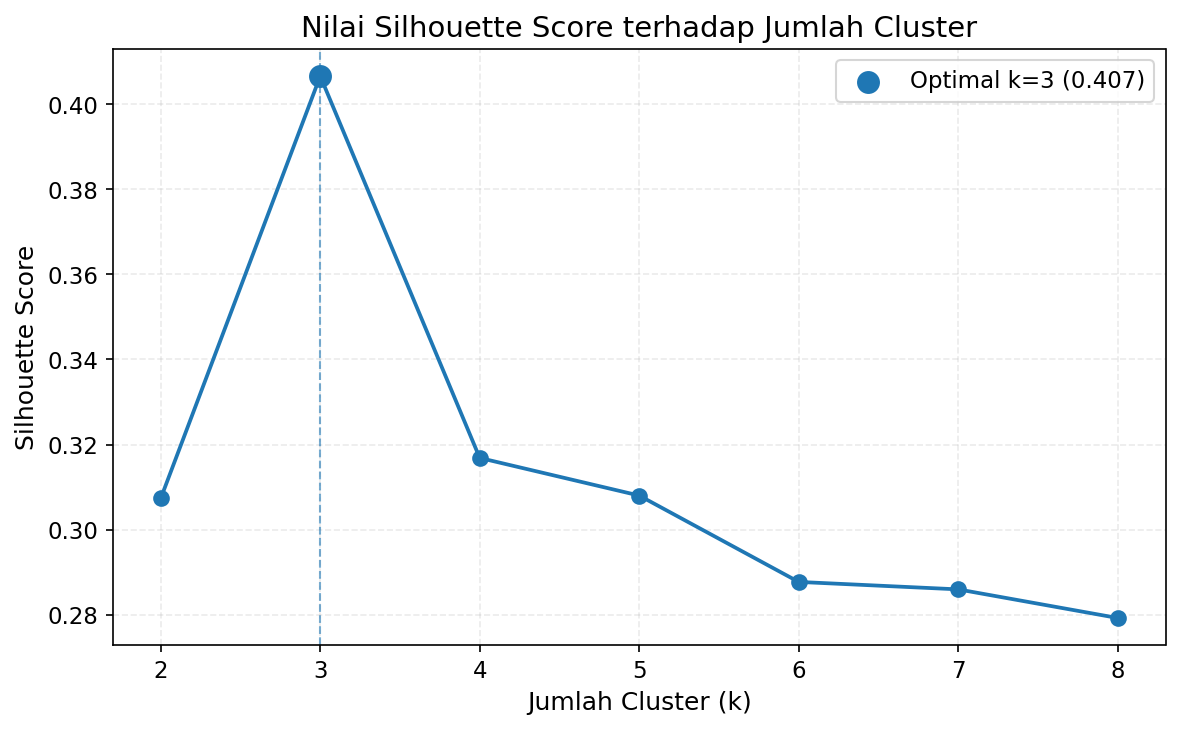


Gambar 3.6 tersimpan:
output_3_1_2\Gambar_3.6_Silhouette_Score.png

HASIL FINAL 3.1.2.2

TABEL 3.4
 Jumlah Cluster (k)  Silhouette Score
                  2            0.3074
                  3            0.4066
                  4            0.3169
                  5            0.3080
                  6            0.2877
                  7            0.2860
                  8            0.2792

Jumlah cluster optimal: 3
Silhouette Score optimal: 0.4066

Ukuran cluster:
 Cluster  Jumlah Anggota  Persentase (%)
       1             158           40.31
       2             198           50.51
       3              36            9.18

Medoid cluster:
 Cluster    SID Medoid Nama Siklon  Latitude Genesis  Longitude Genesis Zona Genesis
       1 2006252N13139    SHANSHAN              16.3              135.2        Utara
       2 2020291N06141      SAUDEL              13.5              129.4        Utara
       3 2019093S07133     WALLACE              -9.0              132.1      Selata

In [5]:
# ============================================================
# BAB III - 3.1.2.2
# PENENTUAN JUMLAH CLUSTER OPTIMAL
#
# Metode:
# 1. Seleksi SID berdasarkan genesis dalam domain penelitian
# 2. Resampling trajektori
# 3. Dynamic Time Warping (DTW)
# 4. K-Medoids
# 5. Silhouette Score untuk k = 2 sampai 8
#
# Output:
# - Gambar 3.6 Silhouette Score
# - Tabel 3.4 Evaluasi Clustering
# - Assignment cluster optimal per SID
# - Daftar medoid setiap cluster
# - Matriks DTW (.npy) untuk analisis berikutnya
# ============================================================


# ============================================================
# 0. IMPORT LIBRARY
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numba import njit, prange

from sklearn.metrics import silhouette_score

from openpyxl import load_workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)


# ============================================================
# 1. PENGATURAN FILE
# ============================================================

FILE_PATH = "Siklon_Tropis_ERA5_Extracted.xlsx"
SHEET_NAME = "Sheet1"

OUTPUT_DIR = "output_3_1_2"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


OUTPUT_EXCEL = os.path.join(
    OUTPUT_DIR,
    "Hasil_3_1_2_2_Clustering.xlsx"
)

OUTPUT_G36 = os.path.join(
    OUTPUT_DIR,
    "Gambar_3.6_Silhouette_Score.png"
)

OUTPUT_DTW = os.path.join(
    OUTPUT_DIR,
    "DTW_Distance_Matrix.npy"
)

OUTPUT_SID = os.path.join(
    OUTPUT_DIR,
    "DTW_SID_Order.npy"
)


# ============================================================
# 2. DOMAIN PENELITIAN
# ============================================================

LON_MIN = 95
LON_MAX = 145

LAT_MIN = -15
LAT_MAX = 25

EQ_MIN = -5
EQ_MAX = 5

YEAR_START = 2001
YEAR_END = 2025


# ============================================================
# 3. PENGATURAN CLUSTERING
# ============================================================

K_MIN = 2
K_MAX = 8

RANDOM_STATE = 42

# Beberapa inisialisasi dilakukan agar solusi K-Medoids
# tidak terlalu bergantung pada satu initial medoid.
N_INIT = 30

MAX_ITER = 100


# ============================================================
# 4. PENGATURAN VISUAL
# ============================================================

plt.rcParams.update({

    "font.size": 11,

    "axes.labelsize": 12,

    "axes.titlesize": 14,

    "figure.dpi": 150,

    "savefig.dpi": 300,

    "font.family": "DejaVu Sans"

})


# ============================================================
# 5. BACA DATA
# ============================================================

df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME
)


# ============================================================
# 6. CLEANING
# ============================================================

df["ISO_TIME"] = pd.to_datetime(
    df["ISO_TIME"],
    errors="coerce"
)

df["LAT"] = pd.to_numeric(
    df["LAT"],
    errors="coerce"
)

df["LON"] = pd.to_numeric(
    df["LON"],
    errors="coerce"
)

df["SEASON"] = pd.to_numeric(
    df["SEASON"],
    errors="coerce"
)


df = df.dropna(
    subset=[
        "SID",
        "ISO_TIME",
        "LAT",
        "LON"
    ]
).copy()


df = df[
    df["LAT"].between(-90, 90)
].copy()

df = df[
    df["LON"].between(-180, 360)
].copy()


df = df.drop_duplicates(
    subset=[
        "SID",
        "ISO_TIME"
    ],
    keep="first"
)


df = df.sort_values(
    [
        "SID",
        "ISO_TIME"
    ]
).reset_index(
    drop=True
)


# ============================================================
# 7. IDENTIFIKASI GENESIS
# ============================================================

genesis_all = (

    df.drop_duplicates(
        subset="SID",
        keep="first"
    )

    .copy()

)


genesis_all = genesis_all[

    genesis_all["SEASON"].between(
        YEAR_START,
        YEAR_END
    )

].copy()


# ============================================================
# 8. FILTER DOMAIN PENELITIAN
# ============================================================

genesis = genesis_all[

    genesis_all["LON"].between(
        LON_MIN,
        LON_MAX
    )

    &

    genesis_all["LAT"].between(
        LAT_MIN,
        LAT_MAX
    )

].copy()


# ============================================================
# 9. ZONA GENESIS
# ============================================================

def get_zone(lat):

    if EQ_MIN <= lat <= EQ_MAX:

        return "Ekuatorial"

    elif lat > EQ_MAX:

        return "Utara"

    else:

        return "Selatan"


genesis["Genesis_Zone"] = (
    genesis["LAT"]
    .apply(get_zone)
)


# ============================================================
# 10. AMBIL SELURUH TRACK SID TERPILIH
# ============================================================

selected_sids = (
    genesis["SID"]
    .unique()
)


track = df[

    df["SID"].isin(
        selected_sids
    )

].copy()


print("=" * 70)
print("DATA CLUSTERING")
print("=" * 70)

print(
    "Jumlah SID:",
    len(selected_sids)
)

print(
    "Jumlah titik track:",
    len(track)
)

print("=" * 70)


# Quality control
if len(selected_sids) != 392:

    print(
        "PERINGATAN: "
        "Jumlah SID bukan 392."
    )


# ============================================================
# 11. JUMLAH TITIK SETIAP TRAJEKTORI
# ============================================================

points_per_track = (

    track

    .groupby(
        "SID"
    )

    .size()

)


print(
    "\nStatistik jumlah titik per trajektori:"
)

print(
    points_per_track.describe()
)


# ============================================================
# 12. JUMLAH TITIK RESAMPLING
# ============================================================
#
# Menggunakan median jumlah titik observasi agar:
# - trajektori pendek tidak terlalu banyak ditambah titik
# - trajektori panjang tidak terlalu banyak kehilangan informasi
#
# Dataset saat ini menghasilkan median = 44.
# ============================================================

N_RESAMPLE = int(
    round(
        points_per_track.median()
    )
)


print(
    "\nJumlah titik resampling:",
    N_RESAMPLE
)


# ============================================================
# 13. FUNGSI RESAMPLING TRAJEKTORI
# ============================================================
#
# Waktu setiap lintasan dinormalisasi:
#
# genesis = 0
# terminasi = 1
#
# Kemudian latitude dan longitude diinterpolasi secara linear.
# ============================================================

def resample_trajectory(
    group,
    n_points
):

    group = group.sort_values(
        "ISO_TIME"
    ).copy()


    lat = (
        group["LAT"]
        .to_numpy(
            dtype=float
        )
    )


    lon = (
        group["LON"]
        .to_numpy(
            dtype=float
        )
    )


    # Waktu relatif dalam detik
    relative_time = (

        group["ISO_TIME"]

        -

        group[
            "ISO_TIME"
        ].iloc[0]

    ).dt.total_seconds().to_numpy(
        dtype=float
    )


    # Jika hanya satu posisi
    # atau durasi nol
    if (
        len(group) == 1
        or
        relative_time[-1] == 0
    ):

        lat_new = np.full(
            n_points,
            lat[0]
        )

        lon_new = np.full(
            n_points,
            lon[0]
        )

        return np.column_stack(
            [
                lat_new,
                lon_new
            ]
        )


    # Normalisasi waktu 0-1
    normalized_time = (

        relative_time

        /

        relative_time[-1]

    )


    target_time = np.linspace(
        0,
        1,
        n_points
    )


    # Interpolasi latitude
    lat_new = np.interp(

        target_time,

        normalized_time,

        lat

    )


    # Interpolasi longitude
    lon_new = np.interp(

        target_time,

        normalized_time,

        lon

    )


    return np.column_stack(
        [
            lat_new,
            lon_new
        ]
    )


# ============================================================
# 14. RESAMPLE SELURUH TRAJEKTORI
# ============================================================

sid_order = []

resampled_tracks = []


for sid, group in track.groupby(
    "SID"
):

    sid_order.append(
        sid
    )


    resampled_tracks.append(

        resample_trajectory(

            group,

            N_RESAMPLE

        )

    )


resampled_tracks = np.stack(
    resampled_tracks
)


sid_order = np.array(
    sid_order
)


print(
    "\nShape data trajektori:"
)

print(
    resampled_tracks.shape
)


# ============================================================
# 15. JARAK HAVERSINE
# ============================================================
#
# Digunakan sebagai local distance di dalam DTW.
# Output dalam kilometer.
# ============================================================

EARTH_RADIUS_KM = 6371.0088


@njit
def haversine_numba(
    lat1,
    lon1,
    lat2,
    lon2
):

    p1 = (
        lat1
        *
        np.pi
        /
        180.0
    )


    p2 = (
        lat2
        *
        np.pi
        /
        180.0
    )


    dlat = (

        (
            lat2
            -
            lat1
        )

        *

        np.pi

        /

        180.0

    )


    dlon = (

        (
            lon2
            -
            lon1
        )

        *

        np.pi

        /

        180.0

    )


    a = (

        np.sin(
            dlat / 2.0
        ) ** 2

        +

        np.cos(
            p1
        )

        *

        np.cos(
            p2
        )

        *

        np.sin(
            dlon / 2.0
        ) ** 2

    )


    c = (

        2.0

        *

        np.arctan2(

            np.sqrt(a),

            np.sqrt(
                1.0 - a
            )

        )

    )


    return (
        EARTH_RADIUS_KM
        *
        c
    )


# ============================================================
# 16. DYNAMIC TIME WARPING
# ============================================================

@njit
def dtw_distance(
    track_a,
    track_b
):

    n = track_a.shape[0]

    m = track_b.shape[0]


    # Hanya menyimpan dua baris
    # agar penggunaan memori lebih rendah.
    previous = np.full(
        m + 1,
        1e30
    )


    current = np.full(
        m + 1,
        1e30
    )


    previous[0] = 0.0


    for i in range(
        1,
        n + 1
    ):


        current[0] = 1e30


        for j in range(
            1,
            m + 1
        ):


            cost = haversine_numba(

                track_a[
                    i - 1,
                    0
                ],

                track_a[
                    i - 1,
                    1
                ],

                track_b[
                    j - 1,
                    0
                ],

                track_b[
                    j - 1,
                    1
                ]

            )


            minimum_previous = previous[
                j
            ]


            if (
                current[
                    j - 1
                ]
                <
                minimum_previous
            ):

                minimum_previous = current[
                    j - 1
                ]


            if (
                previous[
                    j - 1
                ]
                <
                minimum_previous
            ):

                minimum_previous = previous[
                    j - 1
                ]


            current[
                j
            ] = (

                cost

                +

                minimum_previous

            )


        temporary = previous

        previous = current

        current = temporary


    return previous[m]


# ============================================================
# 17. MATRIKS JARAK DTW
# ============================================================

@njit(
    parallel=True
)
def pairwise_dtw_matrix(
    trajectories
):

    n_track = (
        trajectories.shape[0]
    )


    distance_matrix = np.zeros(

        (
            n_track,
            n_track
        ),

        dtype=np.float64

    )


    for i in prange(
        n_track
    ):


        for j in range(
            i + 1,
            n_track
        ):


            distance = dtw_distance(

                trajectories[i],

                trajectories[j]

            )


            distance_matrix[
                i,
                j
            ] = distance


            distance_matrix[
                j,
                i
            ] = distance


    return distance_matrix


print(
    "\nMenghitung matriks DTW..."
)


# Pemanggilan pertama juga melakukan
# kompilasi fungsi Numba.
distance_matrix = pairwise_dtw_matrix(
    resampled_tracks
)


print(
    "Matriks DTW selesai."
)


print(
    "Shape matriks:",
    distance_matrix.shape
)


# Simpan agar tidak perlu dihitung ulang
np.save(
    OUTPUT_DTW,
    distance_matrix
)


np.save(
    OUTPUT_SID,
    sid_order
)


# ============================================================
# 18. INISIALISASI K-MEDOIDS++
# ============================================================

def initialize_kmedoids_pp(
    distance_matrix,
    k,
    rng
):

    n = (
        distance_matrix.shape[0]
    )


    # Medoid pertama acak
    medoids = [

        int(
            rng.integers(
                n
            )
        )

    ]


    while len(
        medoids
    ) < k:


        nearest_distance = np.min(

            distance_matrix[
                :,
                medoids
            ],

            axis=1

        )


        # Jangan pilih medoid yang sama
        nearest_distance[
            medoids
        ] = 0.0


        probabilities = (

            nearest_distance
            **
            2

        )


        total = (
            probabilities.sum()
        )


        if total <= 0:


            candidates = np.setdiff1d(

                np.arange(
                    n
                ),

                np.array(
                    medoids
                )

            )


            new_medoid = int(

                rng.choice(
                    candidates
                )

            )


        else:


            probabilities = (

                probabilities

                /

                total

            )


            new_medoid = int(

                rng.choice(

                    n,

                    p=probabilities

                )

            )


        if (
            new_medoid
            not in medoids
        ):

            medoids.append(
                new_medoid
            )


    return np.array(

        medoids,

        dtype=int

    )


# ============================================================
# 19. K-MEDOIDS
# ============================================================

def kmedoids_precomputed(
    distance_matrix,
    k,
    random_state=42,
    n_init=30,
    max_iter=100
):

    n = (
        distance_matrix.shape[0]
    )


    base_rng = np.random.default_rng(
        random_state
    )


    seeds = base_rng.integers(

        0,

        2**32 - 1,

        size=n_init,

        dtype=np.uint32

    )


    best_result = None


    for seed in seeds:


        rng = np.random.default_rng(
            int(seed)
        )


        medoids = initialize_kmedoids_pp(

            distance_matrix,

            k,

            rng

        )


        labels = None


        for iteration in range(
            max_iter
        ):


            # ----------------------------------------------
            # Assignment
            # ----------------------------------------------

            labels = np.argmin(

                distance_matrix[
                    :,
                    medoids
                ],

                axis=1

            )


            new_medoids = (
                medoids.copy()
            )


            # ----------------------------------------------
            # Update medoid setiap cluster
            # ----------------------------------------------

            for cluster_id in range(
                k
            ):


                members = np.where(

                    labels
                    ==
                    cluster_id

                )[0]


                # Empty cluster
                if len(
                    members
                ) == 0:


                    nearest = np.min(

                        distance_matrix[
                            :,
                            medoids
                        ],

                        axis=1

                    )


                    candidates = np.argsort(
                        nearest
                    )[::-1]


                    for candidate in candidates:


                        if (
                            candidate
                            not in
                            new_medoids
                        ):


                            new_medoids[
                                cluster_id
                            ] = candidate


                            break


                else:


                    sub_matrix = (

                        distance_matrix[
                            np.ix_(
                                members,
                                members
                            )
                        ]

                    )


                    total_distance = (

                        sub_matrix.sum(
                            axis=1
                        )

                    )


                    best_member = (

                        members[

                            np.argmin(
                                total_distance
                            )

                        ]

                    )


                    new_medoids[
                        cluster_id
                    ] = best_member


            # ----------------------------------------------
            # Konvergensi
            # ----------------------------------------------

            if np.array_equal(

                np.sort(
                    new_medoids
                ),

                np.sort(
                    medoids
                )

            ):


                medoids = new_medoids


                labels = np.argmin(

                    distance_matrix[
                        :,
                        medoids
                    ],

                    axis=1

                )


                break


            medoids = new_medoids


        # ----------------------------------------------
        # Objective:
        # jumlah jarak setiap objek
        # terhadap medoid cluster
        # ----------------------------------------------

        inertia = np.sum(

            distance_matrix[

                np.arange(
                    n
                ),

                medoids[
                    labels
                ]

            ]

        )


        if (

            best_result is None

            or

            inertia
            <
            best_result[
                "inertia"
            ]

        ):


            best_result = {

                "medoids":
                    medoids.copy(),

                "labels":
                    labels.copy(),

                "inertia":
                    inertia,

                "n_iter":
                    iteration + 1

            }


    return best_result


# ============================================================
# 20. UJI k = 2 SAMPAI 8
# ============================================================

evaluation_records = []

cluster_results = {}


print(
    "\nMenghitung K-Medoids dan Silhouette Score..."
)


for k in range(
    K_MIN,
    K_MAX + 1
):


    result = kmedoids_precomputed(

        distance_matrix,

        k,

        random_state=RANDOM_STATE,

        n_init=N_INIT,

        max_iter=MAX_ITER

    )


    silhouette = silhouette_score(

        distance_matrix,

        result[
            "labels"
        ],

        metric="precomputed"

    )


    cluster_results[
        k
    ] = result


    evaluation_records.append({

        "Jumlah Cluster (k)":
            k,

        "Silhouette Score":
            silhouette,

        "Total Within-Cluster Distance":
            result[
                "inertia"
            ]

    })


    print(
        f"k = {k} | "
        f"Silhouette = "
        f"{silhouette:.4f}"
    )


evaluation_df = pd.DataFrame(
    evaluation_records
)


# ============================================================
# 21. PILIH k OPTIMAL
# ============================================================

optimal_row = evaluation_df.loc[

    evaluation_df[
        "Silhouette Score"
    ].idxmax()

]


OPTIMAL_K = int(

    optimal_row[
        "Jumlah Cluster (k)"
    ]

)


OPTIMAL_SILHOUETTE = float(

    optimal_row[
        "Silhouette Score"
    ]

)


print(
    "\nJumlah cluster optimal:",
    OPTIMAL_K
)


print(
    "Silhouette Score tertinggi:",
    round(
        OPTIMAL_SILHOUETTE,
        4
    )
)


# ============================================================
# 22. AMBIL HASIL CLUSTER OPTIMAL
# ============================================================

optimal_result = (
    cluster_results[
        OPTIMAL_K
    ]
)


raw_labels = (
    optimal_result[
        "labels"
    ]
)


raw_medoids = (
    optimal_result[
        "medoids"
    ]
)


# ============================================================
# 23. DATA METADATA PER SID
# ============================================================

metadata = (

    genesis[

        [
            "SID",
            "NAME",
            "SEASON",
            "LAT",
            "LON",
            "Genesis_Zone"
        ]

    ]

    .copy()

)


metadata = metadata.rename(
    columns={

        "LAT":
            "Genesis_Lat",

        "LON":
            "Genesis_Lon"

    }
)


# Urut metadata sama persis dengan matriks DTW
metadata = (

    metadata

    .set_index(
        "SID"
    )

    .loc[
        sid_order
    ]

    .reset_index()

)


metadata[
    "Raw_Cluster"
] = (
    raw_labels
)


# ============================================================
# 24. RENUMBER CLUSTER UNTUK PENYAJIAN
# ============================================================
#
# Nomor cluster algoritma sebenarnya arbitrer.
#
# Agar lebih konsisten saat ditampilkan,
# cluster diurutkan berdasarkan median latitude genesis
# dari utara ke selatan.
# ============================================================

cluster_median_lat = (

    metadata

    .groupby(
        "Raw_Cluster"
    )[
        "Genesis_Lat"
    ]

    .median()

    .sort_values(
        ascending=False
    )

)


cluster_mapping = {

    raw_cluster:
        new_cluster

    for new_cluster,
        raw_cluster

    in enumerate(

        cluster_median_lat.index,

        start=1

    )

}


metadata[
    "Cluster"
] = (

    metadata[
        "Raw_Cluster"
    ]

    .map(
        cluster_mapping
    )

)


# ============================================================
# 25. DATA MEDOID
# ============================================================

medoid_records = []


for raw_cluster_id in range(
    OPTIMAL_K
):


    medoid_index = (
        raw_medoids[
            raw_cluster_id
        ]
    )


    medoid_sid = (
        sid_order[
            medoid_index
        ]
    )


    row = metadata[

        metadata[
            "SID"
        ]
        ==
        medoid_sid

    ].iloc[0]


    medoid_records.append({

        "Cluster":
            cluster_mapping[
                raw_cluster_id
            ],

        "SID Medoid":
            row[
                "SID"
            ],

        "Nama Siklon":
            row[
                "NAME"
            ],

        "Latitude Genesis":
            row[
                "Genesis_Lat"
            ],

        "Longitude Genesis":
            row[
                "Genesis_Lon"
            ],

        "Zona Genesis":
            row[
                "Genesis_Zone"
            ]

    })


medoid_df = (

    pd.DataFrame(
        medoid_records
    )

    .sort_values(
        "Cluster"
    )

    .reset_index(
        drop=True
    )

)


# ============================================================
# 26. JUMLAH ANGGOTA CLUSTER
# ============================================================

cluster_size = (

    metadata[
        "Cluster"
    ]

    .value_counts()

    .sort_index()

    .rename_axis(
        "Cluster"
    )

    .reset_index(
        name="Jumlah Anggota"
    )

)


cluster_size[
    "Persentase (%)"
] = (

    cluster_size[
        "Jumlah Anggota"
    ]

    /

    len(
        metadata
    )

    *

    100

)


# ============================================================
# 27. TABEL 3.4
# ============================================================

table_34 = (

    evaluation_df[

        [
            "Jumlah Cluster (k)",
            "Silhouette Score"
        ]

    ]

    .copy()

)


# ============================================================
# 28. RINGKASAN METODE
# ============================================================

method_summary = pd.DataFrame({

    "Parameter": [

        "Jumlah trajektori",

        "Median jumlah titik awal",

        "Jumlah titik resampling",

        "Rentang k yang diuji",

        "Jumlah inisialisasi K-Medoids",

        "Random state",

        "Jumlah cluster optimal",

        "Silhouette Score optimal"

    ],

    "Nilai": [

        len(
            sid_order
        ),

        float(
            points_per_track.median()
        ),

        N_RESAMPLE,

        f"{K_MIN}–{K_MAX}",

        N_INIT,

        RANDOM_STATE,

        OPTIMAL_K,

        round(
            OPTIMAL_SILHOUETTE,
            4
        )

    ]

})


# ============================================================
# 29. SIMPAN KE EXCEL
# ============================================================

with pd.ExcelWriter(

    OUTPUT_EXCEL,

    engine="openpyxl"

) as writer:


    # Tabel yang masuk skripsi
    table_34.round(
        4
    ).to_excel(

        writer,

        sheet_name="Tabel 3.4",

        index=False

    )


    # Ringkasan metode
    method_summary.to_excel(

        writer,

        sheet_name="Ringkasan Metode",

        index=False

    )


    # Assignment untuk analisis 3.1.2.3
    metadata[

        [
            "SID",
            "NAME",
            "SEASON",
            "Genesis_Lat",
            "Genesis_Lon",
            "Genesis_Zone",
            "Cluster"
        ]

    ].to_excel(

        writer,

        sheet_name="Assignment Cluster",

        index=False

    )


    # Jumlah anggota
    cluster_size.round(
        2
    ).to_excel(

        writer,

        sheet_name="Ukuran Cluster",

        index=False

    )


    # Medoid
    medoid_df.to_excel(

        writer,

        sheet_name="Medoid Cluster",

        index=False

    )


# ============================================================
# 30. FORMAT EXCEL
# ============================================================

wb = load_workbook(
    OUTPUT_EXCEL
)


header_fill = PatternFill(
    "solid",
    fgColor="D9EAF7"
)


header_font = Font(
    bold=True
)


thin_border = Border(

    left=Side(
        style="thin",
        color="BFBFBF"
    ),

    right=Side(
        style="thin",
        color="BFBFBF"
    ),

    top=Side(
        style="thin",
        color="BFBFBF"
    ),

    bottom=Side(
        style="thin",
        color="BFBFBF"
    )

)


for ws in wb.worksheets:


    ws.freeze_panes = "A2"


    for cell in ws[1]:

        cell.fill = (
            header_fill
        )

        cell.font = (
            header_font
        )

        cell.alignment = Alignment(

            horizontal="center",

            vertical="center"

        )


    for row in ws.iter_rows():

        for cell in row:

            cell.border = (
                thin_border
            )

            cell.alignment = Alignment(
                vertical="center"
            )


    for column_cells in ws.columns:


        column_letter = (
            column_cells[0]
            .column_letter
        )


        max_length = 0


        for cell in column_cells:


            if cell.value is not None:

                max_length = max(

                    max_length,

                    len(
                        str(
                            cell.value
                        )
                    )

                )


        ws.column_dimensions[
            column_letter
        ].width = min(

            max_length + 2,

            35

        )


wb.save(
    OUTPUT_EXCEL
)


print(
    "\nExcel tersimpan:"
)

print(
    OUTPUT_EXCEL
)


# ============================================================
# 31. GAMBAR 3.6
# SILHOUETTE SCORE TERHADAP JUMLAH CLUSTER
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.plot(

    evaluation_df[
        "Jumlah Cluster (k)"
    ],

    evaluation_df[
        "Silhouette Score"
    ],

    marker="o",

    linewidth=1.8,

    markersize=7

)


# Highlight k optimal
ax.scatter(

    OPTIMAL_K,

    OPTIMAL_SILHOUETTE,

    s=100,

    zorder=5,

    label=(
        f"Optimal k={OPTIMAL_K} "
        f"({OPTIMAL_SILHOUETTE:.3f})"
    )

)


ax.axvline(

    OPTIMAL_K,

    linestyle="--",

    linewidth=1.0,

    alpha=0.6

)


ax.set_xticks(
    range(
        K_MIN,
        K_MAX + 1
    )
)


ax.set_xlabel(
    "Jumlah Cluster (k)"
)


ax.set_ylabel(
    "Silhouette Score"
)


ax.set_title(
    "Nilai Silhouette Score terhadap Jumlah Cluster"
)


ax.grid(
    alpha=0.25,
    linestyle="--"
)


ax.legend()


plt.tight_layout()


plt.savefig(

    OUTPUT_G36,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"

)


plt.show()


print(
    "\nGambar 3.6 tersimpan:"
)

print(
    OUTPUT_G36
)


# ============================================================
# 32. OUTPUT TERMINAL
# ============================================================

print("\n" + "=" * 70)

print(
    "HASIL FINAL 3.1.2.2"
)

print("=" * 70)


print(
    "\nTABEL 3.4"
)


print(

    table_34

    .round(4)

    .to_string(
        index=False
    )

)


print(
    "\nJumlah cluster optimal:",
    OPTIMAL_K
)


print(
    "Silhouette Score optimal:",
    round(
        OPTIMAL_SILHOUETTE,
        4
    )
)


print(
    "\nUkuran cluster:"
)


print(

    cluster_size

    .round(2)

    .to_string(
        index=False
    )

)


print(
    "\nMedoid cluster:"
)


print(

    medoid_df

    .to_string(
        index=False
    )

)


print("=" * 70)

DATA 3.1.2.3
Jumlah SID: 392
Jumlah cluster: 3

Jumlah anggota setiap cluster:
Cluster
1    158
2    198
3     36
Name: count, dtype: int64

Excel berhasil disimpan:
output_3_1_2\Hasil_3_1_2_3_Karakteristik_Cluster.xlsx


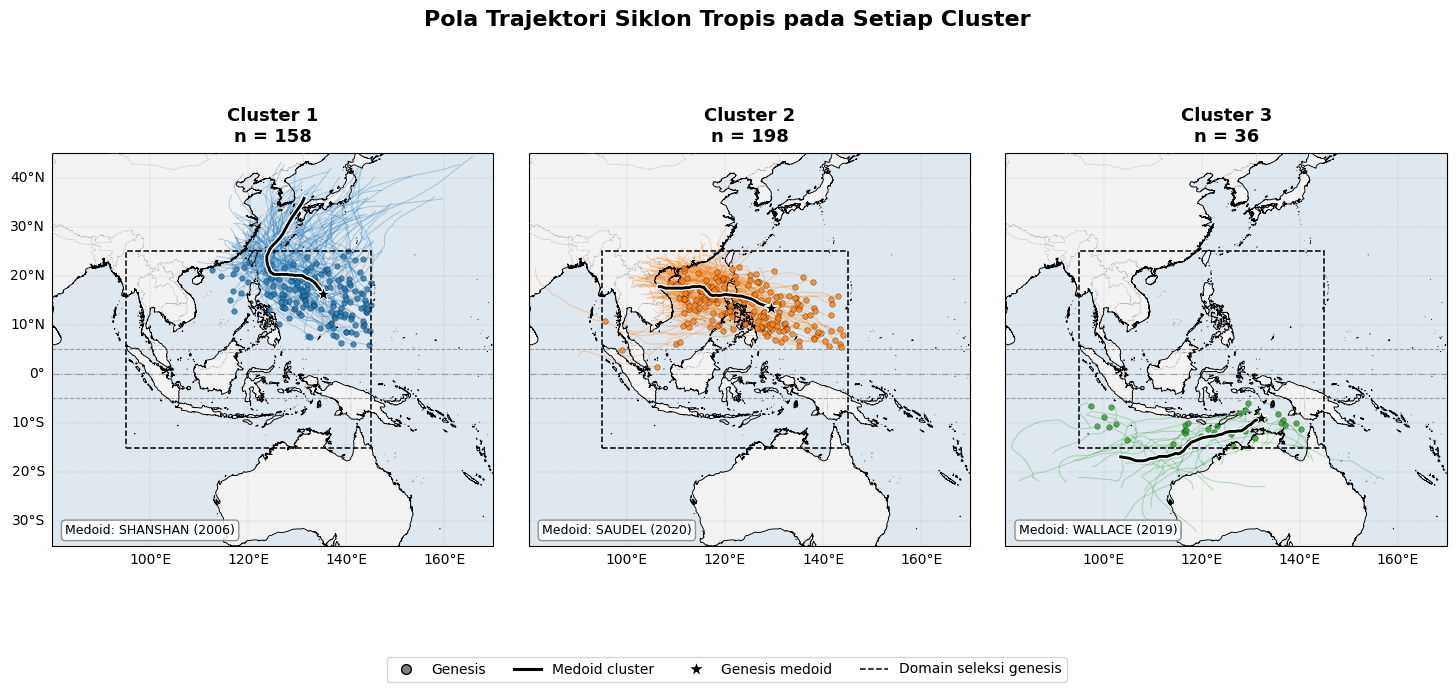


Gambar 3.7 tersimpan:
output_3_1_2\Gambar_3.7_Pola_Trajektori_Per_Cluster.png

TABEL 3.5 KARAKTERISTIK UTAMA SETIAP CLUSTER
 Cluster  Jumlah Trajektori  Persentase (%)  Zona Genesis Dominan            Arah Dominan  Panjang Rata-rata (km)  Durasi Rata-rata (jam)  Durasi Rata-rata (hari)          Medoid
       1                158           40.31  Utara (158; 100.00%)      Utara (63; 39.87%)                 2764.81                  150.10                     6.25 SHANSHAN (2006)
       2                198           50.51   Utara (196; 98.99%)     Barat (110; 55.56%)                 2066.52                  118.41                     4.93   SAUDEL (2020)
       3                 36            9.18 Selatan (36; 100.00%) Barat Daya (17; 47.22%)                 2410.97                  160.83                     6.70  WALLACE (2019)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cartopy.mpl.gridliner import (
    LONGITUDE_FORMATTER,
    LATITUDE_FORMATTER
)

from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle


# ============================================================
# 1. PENGATURAN FILE
# ============================================================

DATA_FILE = "Siklon_Tropis_ERA5_Extracted.xlsx"

CLUSTER_FILE = os.path.join(
    "output_3_1_2",
    "Hasil_3_1_2_2_Clustering.xlsx"
)

OUTPUT_DIR = "output_3_1_2"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


OUTPUT_EXCEL = os.path.join(
    OUTPUT_DIR,
    "Hasil_3_1_2_3_Karakteristik_Cluster.xlsx"
)


OUTPUT_G37 = os.path.join(
    OUTPUT_DIR,
    "Gambar_3.7_Pola_Trajektori_Per_Cluster.png"
)


# ============================================================
# 2. DOMAIN SELEKSI GENESIS
# ============================================================

LON_MIN = 95
LON_MAX = 145

LAT_MIN = -15
LAT_MAX = 25


# Batas zona ekuatorial
EQ_MIN = -5
EQ_MAX = 5


# ============================================================
# 3. DOMAIN TAMPILAN GAMBAR
# ============================================================
#
# Dibuat lebih luas dibanding domain penelitian
# agar lintasan setelah genesis tetap terlihat.
# ============================================================

PLOT_LON_MIN = 80
PLOT_LON_MAX = 170

PLOT_LAT_MIN = -35
PLOT_LAT_MAX = 45


# ============================================================
# 4. WARNA CLUSTER
# ============================================================

CLUSTER_COLORS = {

    1: "#1f77b4",

    2: "#ff7f0e",

    3: "#2ca02c"

}


# ============================================================
# 5. BACA DATA UTAMA
# ============================================================

df = pd.read_excel(
    DATA_FILE,
    sheet_name="Sheet1"
)


# ============================================================
# 6. CLEANING DATA
# ============================================================

df["ISO_TIME"] = pd.to_datetime(
    df["ISO_TIME"],
    errors="coerce"
)

df["LAT"] = pd.to_numeric(
    df["LAT"],
    errors="coerce"
)

df["LON"] = pd.to_numeric(
    df["LON"],
    errors="coerce"
)

df["SEASON"] = pd.to_numeric(
    df["SEASON"],
    errors="coerce"
)


df = df.dropna(
    subset=[
        "SID",
        "ISO_TIME",
        "LAT",
        "LON"
    ]
).copy()


df = df[
    df["LAT"].between(
        -90,
        90
    )
].copy()


df = df[
    df["LON"].between(
        -180,
        360
    )
].copy()


df = df.drop_duplicates(
    subset=[
        "SID",
        "ISO_TIME"
    ],
    keep="first"
)


df = df.sort_values(
    [
        "SID",
        "ISO_TIME"
    ]
).reset_index(
    drop=True
)


# ============================================================
# 7. BACA HASIL CLUSTERING
# ============================================================

if not os.path.exists(
    CLUSTER_FILE
):

    raise FileNotFoundError(

        "File hasil clustering tidak ditemukan.\n"
        "Jalankan terlebih dahulu kode 3.1.2.2.\n"
        f"File yang dicari: {CLUSTER_FILE}"

    )


assignment = pd.read_excel(
    CLUSTER_FILE,
    sheet_name="Assignment Cluster",
    dtype={
        "SID": str
    }
)


medoid_df = pd.read_excel(
    CLUSTER_FILE,
    sheet_name="Medoid Cluster",
    dtype={
        "SID Medoid": str
    }
)


# Pastikan SID utama juga string
df["SID"] = (
    df["SID"]
    .astype(str)
)


# ============================================================
# 8. PILIH TRACK YANG TERMASUK HASIL CLUSTERING
# ============================================================

selected_sids = (
    assignment["SID"]
    .astype(str)
    .unique()
)


track = df[
    df["SID"].isin(
        selected_sids
    )
].copy()


print("=" * 70)
print("DATA 3.1.2.3")
print("=" * 70)

print(
    "Jumlah SID:",
    assignment["SID"].nunique()
)

print(
    "Jumlah cluster:",
    assignment["Cluster"].nunique()
)

print(
    "\nJumlah anggota setiap cluster:"
)

print(
    assignment["Cluster"]
    .value_counts()
    .sort_index()
)

print("=" * 70)


# ============================================================
# 9. FUNGSI HAVERSINE
# ============================================================

EARTH_RADIUS_KM = 6371.0088


def haversine(
    lat1,
    lon1,
    lat2,
    lon2
):

    lat1 = np.radians(
        lat1
    )

    lon1 = np.radians(
        lon1
    )

    lat2 = np.radians(
        lat2
    )

    lon2 = np.radians(
        lon2
    )


    dlat = (
        lat2 - lat1
    )

    dlon = (
        lon2 - lon1
    )


    a = (

        np.sin(
            dlat / 2
        ) ** 2

        +

        np.cos(
            lat1
        )

        *

        np.cos(
            lat2
        )

        *

        np.sin(
            dlon / 2
        ) ** 2

    )


    c = (

        2

        *

        np.arctan2(

            np.sqrt(a),

            np.sqrt(
                1 - a
            )

        )

    )


    return (
        EARTH_RADIUS_KM
        *
        c
    )


# ============================================================
# 10. FUNGSI BEARING
# ============================================================

def calculate_bearing(
    lat1,
    lon1,
    lat2,
    lon2
):

    lat1 = np.radians(
        lat1
    )

    lat2 = np.radians(
        lat2
    )


    delta_lon = np.radians(
        lon2 - lon1
    )


    x = (

        np.sin(
            delta_lon
        )

        *

        np.cos(
            lat2
        )

    )


    y = (

        np.cos(
            lat1
        )

        *

        np.sin(
            lat2
        )

        -

        np.sin(
            lat1
        )

        *

        np.cos(
            lat2
        )

        *

        np.cos(
            delta_lon
        )

    )


    bearing = np.degrees(

        np.arctan2(
            x,
            y
        )

    )


    return (
        bearing + 360
    ) % 360


# ============================================================
# 11. KLASIFIKASI ARAH
# ============================================================

def bearing_to_direction(
    bearing
):

    directions = [

        "Utara",

        "Timur Laut",

        "Timur",

        "Tenggara",

        "Selatan",

        "Barat Daya",

        "Barat",

        "Barat Laut"

    ]


    index = int(

        (

            (
                bearing + 22.5
            )

            %

            360

        )

        /

        45

    )


    return directions[
        index
    ]


# ============================================================
# 12. HITUNG KARAKTERISTIK SETIAP SID
# ============================================================

records = []


for sid, g in track.groupby(
    "SID"
):


    g = g.sort_values(
        "ISO_TIME"
    ).copy()


    lat = (
        g["LAT"]
        .to_numpy(
            dtype=float
        )
    )


    lon = (
        g["LON"]
        .to_numpy(
            dtype=float
        )
    )


    # --------------------------------------------------------
    # Panjang lintasan
    # --------------------------------------------------------

    if len(g) >= 2:

        segment_distance = haversine(

            lat[:-1],

            lon[:-1],

            lat[1:],

            lon[1:]

        )


        track_length = np.nansum(
            segment_distance
        )

    else:

        track_length = 0


    # --------------------------------------------------------
    # Durasi
    # --------------------------------------------------------

    duration_hours = (

        (
            g["ISO_TIME"].iloc[-1]

            -

            g["ISO_TIME"].iloc[0]
        )

        .total_seconds()

        /

        3600

    )


    # --------------------------------------------------------
    # Bearing genesis -> terminasi
    # --------------------------------------------------------

    bearing = calculate_bearing(

        lat[0],

        lon[0],

        lat[-1],

        lon[-1]

    )


    direction = bearing_to_direction(
        bearing
    )


    records.append({

        "SID":
            sid,

        "Track_Length_km":
            track_length,

        "Duration_Hours":
            duration_hours,

        "Duration_Days":
            duration_hours / 24,

        "Termination_Lat":
            lat[-1],

        "Termination_Lon":
            lon[-1],

        "Bearing_deg":
            bearing,

        "Direction":
            direction

    })


trajectory_stats = pd.DataFrame(
    records
)


# ============================================================
# 13. GABUNGKAN DENGAN ASSIGNMENT CLUSTER
# ============================================================

cluster_data = assignment.merge(

    trajectory_stats,

    on="SID",

    how="left"

)


# ============================================================
# 14. DISTRIBUSI ZONA PER CLUSTER
# ============================================================

zone_distribution = (

    cluster_data

    .groupby(
        [
            "Cluster",
            "Genesis_Zone"
        ]
    )

    .size()

    .reset_index(
        name="Jumlah"
    )

)


zone_distribution[
    "Persentase dalam Cluster (%)"
] = (

    zone_distribution[
        "Jumlah"
    ]

    /

    zone_distribution[
        "Cluster"
    ].map(

        cluster_data[
            "Cluster"
        ]
        .value_counts()

    )

    *

    100

)


# ============================================================
# 15. DISTRIBUSI ARAH PER CLUSTER
# ============================================================

direction_distribution = (

    cluster_data

    .groupby(
        [
            "Cluster",
            "Direction"
        ]
    )

    .size()

    .reset_index(
        name="Jumlah"
    )

)


direction_distribution[
    "Persentase dalam Cluster (%)"
] = (

    direction_distribution[
        "Jumlah"
    ]

    /

    direction_distribution[
        "Cluster"
    ].map(

        cluster_data[
            "Cluster"
        ]
        .value_counts()

    )

    *

    100

)


# ============================================================
# 16. BUAT TABEL 3.5
# ============================================================

summary_records = []


for cluster_id in sorted(
    cluster_data["Cluster"].unique()
):


    g = cluster_data[
        cluster_data["Cluster"]
        ==
        cluster_id
    ].copy()


    # --------------------------------------------------------
    # Zona dominan
    # --------------------------------------------------------

    zone_counts = (
        g["Genesis_Zone"]
        .value_counts()
    )


    dominant_zone = (
        zone_counts.index[0]
    )


    dominant_zone_n = int(
        zone_counts.iloc[0]
    )


    dominant_zone_pct = (

        dominant_zone_n

        /

        len(g)

        *

        100

    )


    # --------------------------------------------------------
    # Arah dominan
    # --------------------------------------------------------

    direction_counts = (
        g["Direction"]
        .value_counts()
    )


    dominant_direction = (
        direction_counts.index[0]
    )


    dominant_direction_n = int(
        direction_counts.iloc[0]
    )


    dominant_direction_pct = (

        dominant_direction_n

        /

        len(g)

        *

        100

    )


    # --------------------------------------------------------
    # Medoid
    # --------------------------------------------------------

    medoid_row = medoid_df[

        medoid_df[
            "Cluster"
        ]

        ==

        cluster_id

    ].iloc[0]


    medoid_name = (
        medoid_row[
            "Nama Siklon"
        ]
    )


    medoid_sid = (
        medoid_row[
            "SID Medoid"
        ]
    )


    # Cari season medoid
    medoid_meta = assignment[

        assignment[
            "SID"
        ]

        ==

        medoid_sid

    ]


    if len(
        medoid_meta
    ) > 0:

        medoid_year = int(
            medoid_meta[
                "SEASON"
            ].iloc[0]
        )

    else:

        medoid_year = ""


    # --------------------------------------------------------
    # Simpan
    # --------------------------------------------------------

    summary_records.append({

        "Cluster":
            cluster_id,

        "Jumlah Trajektori":
            len(g),

        "Persentase (%)":
            len(g)
            /
            len(cluster_data)
            *
            100,

        "Zona Genesis Dominan":
            (
                f"{dominant_zone} "
                f"({dominant_zone_n}; "
                f"{dominant_zone_pct:.2f}%)"
            ),

        "Arah Dominan":
            (
                f"{dominant_direction} "
                f"({dominant_direction_n}; "
                f"{dominant_direction_pct:.2f}%)"
            ),

        "Panjang Rata-rata (km)":
            g[
                "Track_Length_km"
            ].mean(),

        "Durasi Rata-rata (jam)":
            g[
                "Duration_Hours"
            ].mean(),

        "Durasi Rata-rata (hari)":
            g[
                "Duration_Days"
            ].mean(),

        "Medoid":
            (
                f"{medoid_name} "
                f"({medoid_year})"
            )

    })


table_35 = pd.DataFrame(
    summary_records
)


# ============================================================
# 17. STATISTIK TAMBAHAN PER CLUSTER
# ============================================================

cluster_statistics = (

    cluster_data

    .groupby(
        "Cluster"
    )

    .agg(

        Jumlah_Trajektori=(
            "SID",
            "count"
        ),

        Genesis_Lat_Rata2=(
            "Genesis_Lat",
            "mean"
        ),

        Genesis_Lon_Rata2=(
            "Genesis_Lon",
            "mean"
        ),

        Genesis_Lat_Median=(
            "Genesis_Lat",
            "median"
        ),

        Genesis_Lon_Median=(
            "Genesis_Lon",
            "median"
        ),

        Panjang_Rata2_km=(
            "Track_Length_km",
            "mean"
        ),

        Panjang_Median_km=(
            "Track_Length_km",
            "median"
        ),

        Durasi_Rata2_jam=(
            "Duration_Hours",
            "mean"
        ),

        Durasi_Median_jam=(
            "Duration_Hours",
            "median"
        ),

        Terminasi_Lat_Rata2=(
            "Termination_Lat",
            "mean"
        ),

        Terminasi_Lon_Rata2=(
            "Termination_Lon",
            "mean"
        )

    )

    .reset_index()

)


# ============================================================
# 18. SIMPAN HASIL KE EXCEL
# ============================================================

with pd.ExcelWriter(
    OUTPUT_EXCEL,
    engine="openpyxl"
) as writer:


    table_35.round(
        2
    ).to_excel(

        writer,

        sheet_name="Tabel 3.5",

        index=False

    )


    cluster_statistics.round(
        2
    ).to_excel(

        writer,

        sheet_name="Statistik Cluster",

        index=False

    )


    zone_distribution.round(
        2
    ).to_excel(

        writer,

        sheet_name="Distribusi Zona",

        index=False

    )


    direction_distribution.round(
        2
    ).to_excel(

        writer,

        sheet_name="Distribusi Arah",

        index=False

    )


    medoid_df.to_excel(

        writer,

        sheet_name="Medoid Cluster",

        index=False

    )


    cluster_data.to_excel(

        writer,

        sheet_name="Data per SID",

        index=False

    )


print(
    "\nExcel berhasil disimpan:"
)

print(
    OUTPUT_EXCEL
)


# ============================================================
# 19. GAMBAR 3.7
# POLA TRAJEKTORI SETIAP CLUSTER
# ============================================================

fig, axes = plt.subplots(

    1,
    3,

    figsize=(
        18,
        7
    ),

    subplot_kw={
        "projection":
            ccrs.PlateCarree()
    }

)


for ax, cluster_id in zip(

    axes,

    sorted(
        cluster_data[
            "Cluster"
        ].unique()
    )

):


    color = (
        CLUSTER_COLORS[
            cluster_id
        ]
    )


    cluster_members = cluster_data[

        cluster_data[
            "Cluster"
        ]

        ==

        cluster_id

    ]


    cluster_sids = (

        cluster_members[
            "SID"
        ]

        .astype(str)

        .tolist()

    )


    # --------------------------------------------------------
    # Extent
    # --------------------------------------------------------

    ax.set_extent(

        [
            PLOT_LON_MIN,
            PLOT_LON_MAX,
            PLOT_LAT_MIN,
            PLOT_LAT_MAX
        ],

        crs=ccrs.PlateCarree()

    )


    # --------------------------------------------------------
    # Basemap
    # --------------------------------------------------------

    ax.add_feature(

        cfeature.OCEAN.with_scale(
            "10m"
        ),

        facecolor="#dfe8ef",

        zorder=0

    )


    ax.add_feature(

        cfeature.LAND.with_scale(
            "10m"
        ),

        facecolor="#f2f2f2",

        zorder=0

    )


    ax.add_feature(

        cfeature.COASTLINE.with_scale(
            "10m"
        ),

        linewidth=0.65,

        edgecolor="black",

        zorder=4

    )


    ax.add_feature(

        cfeature.BORDERS.with_scale(
            "10m"
        ),

        linewidth=0.35,

        linestyle=":",

        edgecolor="gray",

        zorder=4

    )


    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    gl = ax.gridlines(

        draw_labels=True,

        linewidth=0.3,

        color="gray",

        alpha=0.4,

        linestyle="--"

    )


    gl.top_labels = False
    gl.right_labels = False

    gl.xformatter = (
        LONGITUDE_FORMATTER
    )

    gl.yformatter = (
        LATITUDE_FORMATTER
    )


    # Hanya panel pertama
    # menampilkan label latitude
    if cluster_id != 1:

        gl.left_labels = False


    # --------------------------------------------------------
    # Batas zona
    # --------------------------------------------------------

    for lat_line, style in [

        (
            5,
            "--"
        ),

        (
            0,
            "-."
        ),

        (
            -5,
            "--"
        )

    ]:


        ax.plot(

            [
                PLOT_LON_MIN,
                PLOT_LON_MAX
            ],

            [
                lat_line,
                lat_line
            ],

            color="gray",

            linestyle=style,

            linewidth=0.8,

            alpha=0.7,

            transform=ccrs.PlateCarree(),

            zorder=2

        )


    # --------------------------------------------------------
    # Kotak domain seleksi genesis
    # --------------------------------------------------------

    domain_rectangle = Rectangle(

        (
            LON_MIN,
            LAT_MIN
        ),

        LON_MAX
        -
        LON_MIN,

        LAT_MAX
        -
        LAT_MIN,

        fill=False,

        edgecolor="black",

        linewidth=1.1,

        linestyle="--",

        transform=ccrs.PlateCarree(),

        zorder=7

    )


    ax.add_patch(
        domain_rectangle
    )


    # --------------------------------------------------------
    # Seluruh track anggota cluster
    # --------------------------------------------------------

    cluster_tracks = track[

        track[
            "SID"
        ].isin(
            cluster_sids
        )

    ]


    for sid, g in cluster_tracks.groupby(
        "SID"
    ):


        g = g.sort_values(
            "ISO_TIME"
        )


        ax.plot(

            g[
                "LON"
            ],

            g[
                "LAT"
            ],

            color=color,

            linewidth=0.75,

            alpha=0.30,

            transform=ccrs.PlateCarree(),

            zorder=2

        )


    # --------------------------------------------------------
    # Genesis anggota cluster
    # --------------------------------------------------------

    ax.scatter(

        cluster_members[
            "Genesis_Lon"
        ],

        cluster_members[
            "Genesis_Lat"
        ],

        s=16,

        color=color,

        edgecolors="black",

        linewidths=0.25,

        alpha=0.80,

        transform=ccrs.PlateCarree(),

        zorder=5

    )


    # --------------------------------------------------------
    # MEDOID CLUSTER
    # --------------------------------------------------------

    medoid_row = medoid_df[

        medoid_df[
            "Cluster"
        ]

        ==

        cluster_id

    ].iloc[0]


    medoid_sid = str(
        medoid_row[
            "SID Medoid"
        ]
    )


    medoid_track = track[

        track[
            "SID"
        ]

        ==

        medoid_sid

    ].sort_values(
        "ISO_TIME"
    )


    # Garis putih sebagai outline
    ax.plot(

        medoid_track[
            "LON"
        ],

        medoid_track[
            "LAT"
        ],

        color="white",

        linewidth=4.0,

        transform=ccrs.PlateCarree(),

        zorder=8

    )


    # Garis hitam medoid
    ax.plot(

        medoid_track[
            "LON"
        ],

        medoid_track[
            "LAT"
        ],

        color="black",

        linewidth=2.1,

        transform=ccrs.PlateCarree(),

        zorder=9

    )


    # Genesis medoid
    ax.scatter(

        medoid_track[
            "LON"
        ].iloc[0],

        medoid_track[
            "LAT"
        ].iloc[0],

        marker="*",

        s=120,

        color="black",

        edgecolor="white",

        linewidth=0.7,

        transform=ccrs.PlateCarree(),

        zorder=10

    )


    # --------------------------------------------------------
    # Nama medoid
    # --------------------------------------------------------

    medoid_name = (
        medoid_row[
            "Nama Siklon"
        ]
    )


    medoid_meta = assignment[

        assignment[
            "SID"
        ]

        ==

        medoid_sid

    ]


    if len(
        medoid_meta
    ) > 0:

        medoid_year = int(
            medoid_meta[
                "SEASON"
            ].iloc[0]
        )

    else:

        medoid_year = ""


    # --------------------------------------------------------
    # Judul panel
    # --------------------------------------------------------

    ax.set_title(

        (
            f"Cluster {cluster_id}\n"
            f"n = {len(cluster_members)}"
        ),

        fontsize=13,

        fontweight="bold",

        pad=8

    )


    ax.text(

        0.03,

        0.03,

        (
            f"Medoid: "
            f"{medoid_name} "
            f"({medoid_year})"
        ),

        transform=ax.transAxes,

        fontsize=9,

        bbox=dict(

            facecolor="white",

            alpha=0.85,

            edgecolor="gray",

            boxstyle="round,pad=0.3"

        ),

        zorder=20

    )


# ============================================================
# 20. JUDUL UTAMA
# ============================================================

fig.suptitle(

    "Pola Trajektori Siklon Tropis pada Setiap Cluster",

    fontsize=16,

    fontweight="bold",

    y=0.98

)


# ============================================================
# 21. LEGEND HORIZONTAL
# ============================================================

legend_elements = [

    Line2D(

        [0],
        [0],

        marker="o",

        linestyle="None",

        markerfacecolor="gray",

        markeredgecolor="black",

        markersize=7,

        label="Genesis"

    ),

    Line2D(

        [0],
        [0],

        color="black",

        linewidth=2.2,

        label="Medoid cluster"

    ),

    Line2D(

        [0],
        [0],

        marker="*",

        linestyle="None",

        markerfacecolor="black",

        markeredgecolor="white",

        markersize=12,

        label="Genesis medoid"

    ),

    Line2D(

        [0],
        [0],

        color="black",

        linestyle="--",

        linewidth=1.1,

        label="Domain seleksi genesis"

    )

]


fig.legend(

    handles=legend_elements,

    loc="lower center",

    bbox_to_anchor=(
        0.5,
        0.01
    ),

    ncol=4,

    frameon=True,

    fontsize=10

)


# Beri ruang bawah untuk legend
plt.subplots_adjust(

    bottom=0.13,

    top=0.86,

    wspace=0.08

)


# ============================================================
# 22. SIMPAN GAMBAR
# ============================================================

plt.savefig(

    OUTPUT_G37,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"

)


plt.show()


print(
    "\nGambar 3.7 tersimpan:"
)

print(
    OUTPUT_G37
)


# ============================================================
# 23. CETAK TABEL 3.5
# ============================================================

print("\n" + "=" * 80)

print(
    "TABEL 3.5 KARAKTERISTIK UTAMA SETIAP CLUSTER"
)

print("=" * 80)


print(

    table_35

    .round(2)

    .to_string(
        index=False
    )

)


print("=" * 80)